# 1. Импорт библиотек

In [1]:
# Импорт основных библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Библиотеки для машинного обучения
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# 2. Загрузка и разведовательный анализ данных

In [2]:
# Загрузка тренировочных данных
train = pd.read_csv('train.csv')

# Первые 5 строк обучающего набора данных
print("Обучающий набор данных:")
display(train.head())

Обучающий набор данных:


,ID,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal,class
0,0,49.207124,0,4.000000,162.996167,181.108682,0,0,148.227858,1,0.944547,2,0,3,1
1,1,53.628425,1,1.741596,130.233730,276.474630,0,2,152.917139,0,0.119070,2,0,3,0
2,2,49.591426,1,4.000000,146.999012,223.300517,1,2,102.352090,1,1.616747,2,2,7,1
3,3,58.991445,1,4.000000,112.369143,187.245501,0,0,158.164750,1,0.000000,1,1,7,1
4,4,51.053602,1,1.954609,138.032047,238.482868,0,0,172.540828,0,1.150464,1,1,3,0


In [3]:
# Загрузка тествоых данных
test = pd.read_csv('test.csv')

# Первые 5 строк тестового набора данных
print("Набор тестовых данных:")
display(test.head())

Набор тестовых данных:


,ID,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal
0,600000,53.963191,1,4.000000,136.940829,236.862814,0,2,143.961525,1,0.711100,1,2,7
1,600001,49.621479,1,4.000000,122.024651,226.593019,0,2,112.220874,1,0.000000,1,1,7
2,600002,36.933893,1,1.300924,127.585643,351.061046,0,0,177.945922,0,0.313078,1,0,7
3,600003,54.884588,1,3.000000,124.876745,250.370530,0,0,153.176526,0,0.308277,1,1,7
4,600004,71.016392,0,1.746972,120.922600,210.979710,0,0,164.573122,0,1.021370,1,1,3


In [4]:
print("Статистическое описание тестового набора данных:")
test.describe()

Статистическое описание тестового набора данных:


,ID,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal
count,400000.000000,400000.000000,400000.000000,400000.000000,400000.000000,400000.000000,400000.000000,400000.000000,400000.000000,400000.000000,400000.000000,400000.000000,400000.000000,400000.00000
mean,799999.500000,54.406917,0.676858,3.169252,131.369647,249.593475,0.151163,1.025295,149.659088,0.333085,1.050086,1.595072,0.681432,4.70715
std,115470.198175,9.101044,0.467677,0.950585,17.862279,51.720531,0.358208,0.994132,23.065911,0.471317,1.140986,0.628361,0.950323,1.93353
min,600000.000000,27.496874,0.000000,-0.337469,85.830892,94.958220,0.000000,0.000000,58.964662,0.000000,-0.601414,1.000000,0.000000,3.00000
25%,699999.750000,48.021226,0.000000,3.000000,119.942167,216.455450,0.000000,0.000000,135.818008,0.000000,0.000000,1.000000,0.000000,3.00000
50%,799999.500000,55.130138,1.000000,3.000000,129.735888,244.273212,0.000000,2.000000,153.337116,0.000000,0.816276,2.000000,0.000000,3.00000
75%,899999.250000,60.667833,1.000000,4.000000,139.935499,274.357993,0.000000,2.000000,165.216643,1.000000,1.671519,2.000000,1.000000,7.00000
max,999999.000000,80.751628,1.000000,4.000000,212.300808,527.712687,1.000000,2.000000,207.412021,1.000000,6.856219,3.000000,3.000000,7.00000


In [5]:
# Общая информация о тестовом датасете
print("Информация о тестовомнаборе данных:")
test.info()

Информация о тестовомнаборе данных:
<class 'pandas.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 14 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   ID                                    400000 non-null  int64  
 1   age                                   400000 non-null  float64
 2   sex                                   400000 non-null  int64  
 3   chest                                 400000 non-null  float64
 4   resting_blood_pressure                400000 non-null  float64
 5   serum_cholestoral                     400000 non-null  float64
 6   fasting_blood_sugar                   400000 non-null  int64  
 7   resting_electrocardiographic_results  400000 non-null  int64  
 8   maximum_heart_rate_achieved           400000 non-null  float64
 9   exercise_induced_angina               400000 non-null  int64  
 10  oldpeak                               40000

In [6]:
# Проверим пропущенные значения в тестовом наборе данных
print("Пропущенные значения в тестовом наборе данных:")
print(test.isnull().sum())

Пропущенные значения в тестовом наборе данных:
ID                                      0
age                                     0
sex                                     0
chest                                   0
resting_blood_pressure                  0
serum_cholestoral                       0
fasting_blood_sugar                     0
resting_electrocardiographic_results    0
maximum_heart_rate_achieved             0
exercise_induced_angina                 0
oldpeak                                 0
slope                                   0
number_of_major_vessels                 0
thal                                    0
dtype: int64


In [7]:
print("Статистическое описание обучающего набора данных:")
train.describe()

Статистическое описание обучающего набора данных:


,ID,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal,class
count,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000
mean,299999.500000,54.426085,0.677447,3.170247,131.340485,249.592420,0.150757,1.020148,149.592069,0.333502,1.051391,1.596033,0.681303,4.711378,0.444185
std,173205.225094,9.086041,0.467454,0.949618,17.842450,51.699976,0.357812,0.994204,23.072593,0.471464,1.144288,0.629821,0.950669,1.934766,0.496875
min,0.000000,26.061695,0.000000,-0.538498,82.918527,98.326263,0.000000,0.000000,61.844168,0.000000,-0.806788,1.000000,0.000000,3.000000,0.000000
25%,149999.750000,48.078493,0.000000,3.000000,119.924094,216.475964,0.000000,0.000000,135.704237,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,299999.500000,55.133425,1.000000,3.000000,129.727941,244.233699,0.000000,2.000000,153.224828,0.000000,0.811101,2.000000,0.000000,3.000000,0.000000
75%,449999.250000,60.663775,1.000000,4.000000,139.915216,274.345453,0.000000,2.000000,165.165497,1.000000,1.674081,2.000000,1.000000,7.000000,1.000000
max,599999.000000,79.591647,1.000000,4.000000,209.673650,527.755764,1.000000,2.000000,208.735196,1.000000,6.803372,3.000000,3.000000,7.000000,1.000000


In [8]:
# Общая информация об обучающем датасете
print("Информация об обучающем наборе данных:")
train.info()

Информация об обучающем наборе данных:
<class 'pandas.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 15 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   ID                                    600000 non-null  int64  
 1   age                                   600000 non-null  float64
 2   sex                                   600000 non-null  int64  
 3   chest                                 600000 non-null  float64
 4   resting_blood_pressure                600000 non-null  float64
 5   serum_cholestoral                     600000 non-null  float64
 6   fasting_blood_sugar                   600000 non-null  int64  
 7   resting_electrocardiographic_results  600000 non-null  int64  
 8   maximum_heart_rate_achieved           600000 non-null  float64
 9   exercise_induced_angina               600000 non-null  int64  
 10  oldpeak                               60

In [9]:
# Проверка пропущенных значений в обучающем наборе данных
print("Пропущенные значения в обучающем наборе данных:")
print(train.isnull().sum())

Пропущенные значения в обучающем наборе данных:
ID                                      0
age                                     0
sex                                     0
chest                                   0
resting_blood_pressure                  0
serum_cholestoral                       0
fasting_blood_sugar                     0
resting_electrocardiographic_results    0
maximum_heart_rate_achieved             0
exercise_induced_angina                 0
oldpeak                                 0
slope                                   0
number_of_major_vessels                 0
thal                                    0
class                                   0
dtype: int64


## Оценка текущей выполненной части

Сейчас выполнено:
- Загрузка `train.csv` и `test.csv`, просмотр первых строк.
- Базовый EDA: `info()`, `describe()`, проверка пропусков `isnull().sum()`.

Пока **не хватает** (по критериям и для дальнейшего моделирования):
- Корреляционный анализ (heatmap/диаграммы рассеяния).
- Оценка выбросов (boxplot/"ящик с усами", хотя бы для ключевых числовых признаков).
- Проверка/обработка дублей (и базовая проверка явных невалидных значений/диапазонов).
- Явная проверка баланса целевого класса (`class`).
- Раздел “Предобработка данных” пока пустой (кодирование категориальных, масштабирование, разбиение на train/valid и т.п.).

## Мини-выводы по данным (на основе текущего EDA)

- Данные крупные: **600 000** строк в train и **400 000** в test, что хорошо для обучения моделей и стабильной оценки качества.
- Пропусков **нет**: во всех столбцах `train` и `test` показано **0** пропущенных значений.
- Типы признаков уже числовые (`int64`/`float64`). При этом часть признаков по смыслу **категориальные**, хоть и закодированы числами (например: `sex`, `fasting_blood_sugar`, `resting_electrocardiographic_results`, `exercise_induced_angina`, `slope`, `number_of_major_vessels`, `thal`). Их стоит обрабатывать как категориальные/порядковые, чтобы модель не “придумывала” ложную метрику расстояния.
- По описательной статистике train/test похожи (средние/разбросы близки) — явного сдвига распределений между наборами по базовым метрикам не видно.
- Целевая переменная `class` бинарная (0/1). По `mean(class) ≈ 0.444` доля положительного класса около **44%**, то есть дисбаланс **умеренный** (не экстремальный), но лучше всё равно проверить `value_counts()`.
- Есть признаки с потенциально “широкими хвостами”/выбросами (например, `serum_cholestoral`, `resting_blood_pressure`, `oldpeak`) — это нужно подтвердить boxplot’ами и при необходимости использовать robust-скейлинг/клиппинг.
- В `oldpeak` встречаются **отрицательные** значения (примерно до -0.8 по `describe()`) — это не обязательно ошибка (зависит от определения признака/генерации датасета), но стоит проверить распределение и крайние значения.


# 3. Анализ данных

Дубликаты строк в train: 0
Дубликаты ID в train: 0

Распределение целевого класса (кол-во):
 class
0    333489
1    266511
Name: count, dtype: int64

Распределение целевого класса (доля):
 class
0    0.555815
1    0.444185
Name: proportion, dtype: float64


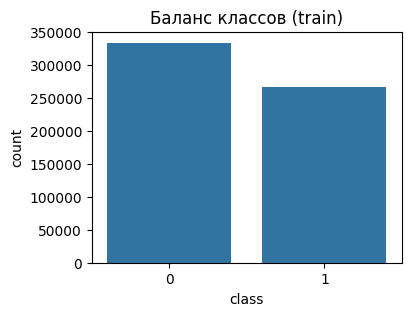


Количество значений вне ожидаемых диапазонов (train):
- sex: 0
- fasting_blood_sugar: 0
- resting_electrocardiographic_results: 0
- exercise_induced_angina: 0
- slope: 0
- number_of_major_vessels: 0
- thal: 0
- chest: 10392


In [10]:
# 3.1 Базовые проверки: дубликаты, баланс классов, базовая валидация диапазонов

# 1) Дубликаты
print("Дубликаты строк в train:", train.duplicated().sum())
print("Дубликаты ID в train:", train["ID"].duplicated().sum())

# 2) Баланс целевого класса
class_counts = train["class"].value_counts().sort_index()
class_share = train["class"].value_counts(normalize=True).sort_index()
print("\nРаспределение целевого класса (кол-во):\n", class_counts)
print("\nРаспределение целевого класса (доля):\n", class_share)

plt.figure(figsize=(4,3))
ax = sns.countplot(x="class", data=train)
ax.set_title("Баланс классов (train)")
ax.set_xlabel("class")
ax.set_ylabel("count")
plt.show()

# 3) Базовая проверка диапазонов категориальных признаков
range_checks = {
    "sex": (0, 1),
    "fasting_blood_sugar": (0, 1),
    "resting_electrocardiographic_results": (0, 2),
    "exercise_induced_angina": (0, 1),
    "slope": (1, 3),
    "number_of_major_vessels": (0, 3),
    "thal": (3, 7),
    "chest": (1, 4),  # по описанию проекта: 1..4
}

bad_values = {}
for col, (lo, hi) in range_checks.items():
    mask = (train[col] < lo) | (train[col] > hi)
    bad_values[col] = int(mask.sum())

print("\nКоличество значений вне ожидаемых диапазонов (train):")
for col, n_bad in bad_values.items():
    print(f"- {col}: {n_bad}")


## 3.2 Корреляционный анализ (числовые признаки)

Ниже считаем корреляции **только по числовым признакам** на исходных данных. Для категориальных признаков в виде “кодированных чисел” корреляция Пирсона может вводить в заблуждение, поэтому для них лучше смотреть распределения по классам.


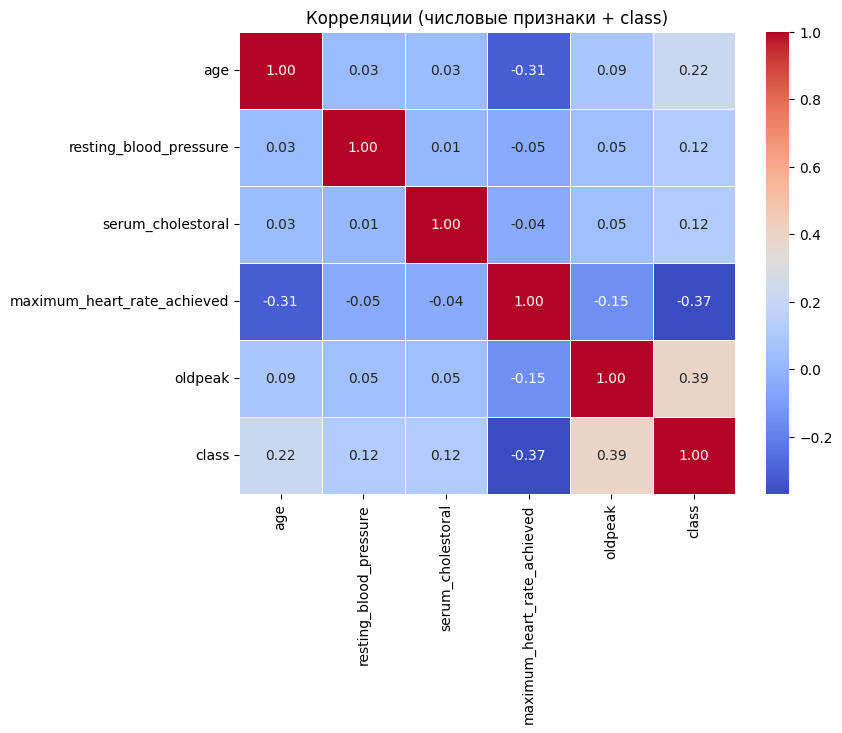

Топ числовых признаков по |corr| с class:
oldpeak                        0.392788
maximum_heart_rate_achieved    0.368760
age                            0.222008
serum_cholestoral              0.117765
resting_blood_pressure         0.115044
Name: class, dtype: float64


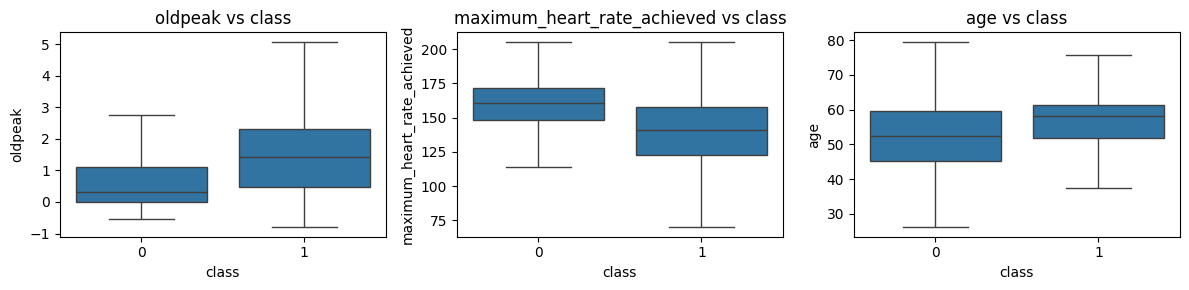

In [11]:
# Корреляционная матрица (по числовым признакам)
num_features = [
    "age",
    "resting_blood_pressure",
    "serum_cholestoral",
    "maximum_heart_rate_achieved",
    "oldpeak",
]

corr_df = train[num_features + ["class"]].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Корреляции (числовые признаки + class)")
plt.show()

# Топ признаков по абсолютной корреляции с class
corr_with_target = corr_df["class"].drop("class").abs().sort_values(ascending=False)
print("Топ числовых признаков по |corr| с class:")
print(corr_with_target)

# Более корректная визуализация для бинарной цели: boxplot признака по классам
top_k = corr_with_target.index[:3]
plt.figure(figsize=(12, 3))
for i, col in enumerate(top_k, start=1):
    plt.subplot(1, 3, i)
    sns.boxplot(x="class", y=col, data=train, showfliers=False)
    plt.title(f"{col} vs class")
plt.tight_layout()
plt.show()


## 3.3 Оценка выбросов (boxplot на исходных шкалах)

Boxplot’ы ниже строятся **до масштабирования**: так “выбросы” видны в исходных единицах и не путаются с отрицательными значениями, которые могли бы появиться просто из-за `StandardScaler`.


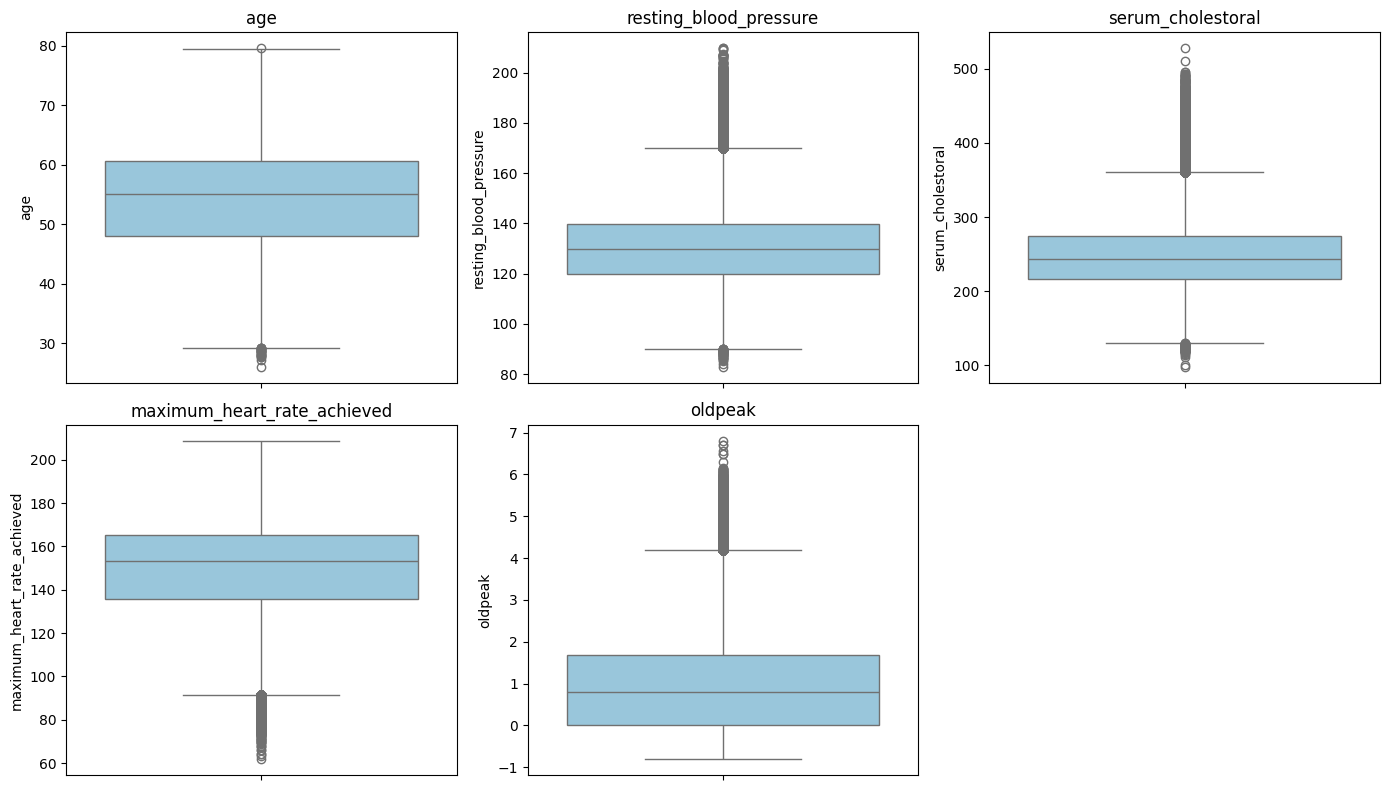

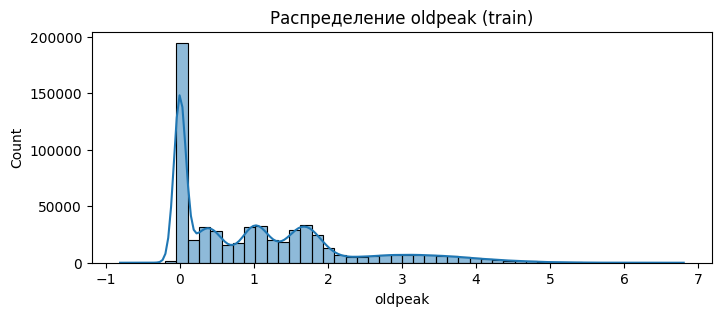

In [12]:
# Boxplot для числовых признаков (сырые значения)

plt.figure(figsize=(14, 8))
for i, col in enumerate(num_features, start=1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=train[col], color="#8ecae6")
    plt.title(col)
plt.tight_layout()
plt.show()

# Дополнительно: распределения oldpeak (есть отрицательные значения)
plt.figure(figsize=(8, 3))
sns.histplot(train["oldpeak"], bins=50, kde=True)
plt.title("Распределение oldpeak (train)")
plt.show()


## Что улучшено по сравнению с `Heart_Disease_example.ipynb`

- Анализ данных вынесен **до** любых преобразований (one-hot/масштабирование), поэтому выводы про распределения и выбросы делаются **в исходной шкале** и не путаются с отрицательными значениями после `StandardScaler`.
- Для корреляций используется аккуратный вариант: считаем корреляции **по числовым** признакам + `class` (а для бинарной цели вместо scatter `feature` vs `class` добавлены **boxplot по классам**, что обычно информативнее).
- Добавлены проверки качества данных, которых не хватало в примере: **дубликаты**, **баланс классов**, **проверка значений категориальных признаков на допустимые диапазоны**.


# 4. Предобработка данных

Дальше — подготовка признаков для моделей (кодирование категориальных, масштабирование числовых, разбиение на train/valid) через пайплайны, чтобы не было рассинхронизации train/test и утечки данных.


In [13]:
# 4.1 Подготовка признаков и разбиение на train/val

TARGET_COL = "class"
DROP_COLS = ["ID"]

# Категориальные признаки
# Важно: `chest` в данных выглядит как float с большим числом уникальных значений,
# поэтому One-Hot для него раздувает матрицу признаков. Оставляем `chest` как числовой.
CAT_FEATURES = [
    "sex",
    "fasting_blood_sugar",
    "resting_electrocardiographic_results",
    "exercise_induced_angina",
    "slope",
    "number_of_major_vessels",
    "thal",
]

# Числовые признаки
NUM_FEATURES = [
    "age",
    "resting_blood_pressure",
    "serum_cholestoral",
    "maximum_heart_rate_achieved",
    "oldpeak",
    "chest",
]

X = train.drop(columns=[TARGET_COL] + DROP_COLS)
y = train[TARGET_COL]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)

# 4.2 Трансформеры
cat_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        # Делаем OHE разреженным, чтобы не раздувать память.
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ]
)

num_pipe_scaled = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

num_pipe_noscale = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

# Для Logistic Regression и Neural Network (со scaler)
preprocess_scaled = ColumnTransformer(
    transformers=[
        ("num", num_pipe_scaled, NUM_FEATURES),
        ("cat", cat_pipe, CAT_FEATURES),
    ],
    remainder="drop",
)

# Для RandomForest (без scaler)
preprocess_noscale = ColumnTransformer(
    transformers=[
        ("num", num_pipe_noscale, NUM_FEATURES),
        ("cat", cat_pipe, CAT_FEATURES),
    ],
    remainder="drop",
)

# 4.3 Подготовленные матрицы
# Для sklearn-моделей удобно оставлять разреженную матрицу (экономит память).
X_train_prepared = preprocess_scaled.fit_transform(X_train)
X_val_prepared = preprocess_scaled.transform(X_val)

print("\nAfter preprocess_scaled:")
print("X_train_prepared shape:", X_train_prepared.shape)
print("X_val_prepared shape:", X_val_prepared.shape)
print("Matrix type:", type(X_train_prepared))

# Список итоговых фич (удобно для интерпретации и отладки)
feature_names = preprocess_scaled.get_feature_names_out()
print("\nTotal features after OHE:", len(feature_names))

# Для нейросети часто нужен dense-массив.
# Важно: переводить 600k строк в dense может быть тяжело по памяти.
# Поэтому ниже — безопасный вариант: готовим dense только для val и небольшого сэмпла train.
X_val_dense = X_val_prepared.toarray() if hasattr(X_val_prepared, "toarray") else X_val_prepared

sample_n = 50000  # можно увеличить/уменьшить при необходимости
X_train_dense = (
    X_train_prepared[:sample_n].toarray()
    if hasattr(X_train_prepared, "toarray")
    else X_train_prepared[:sample_n]
)
y_train_dense = y_train.iloc[:sample_n]

print("\nDense matrices for NN:")
print("X_train_dense:", X_train_dense.shape, "y_train_dense:", y_train_dense.shape)
print("X_val_dense:", X_val_dense.shape, "y_val:", y_val.shape)


Shapes:
X_train: (480000, 13) y_train: (480000,)
X_val: (120000, 13) y_val: (120000,)



After preprocess_scaled:
X_train_prepared shape: (480000, 25)
X_val_prepared shape: (120000, 25)
Matrix type: <class 'numpy.ndarray'>

Total features after OHE: 25

Dense matrices for NN:
X_train_dense: (50000, 25) y_train_dense: (50000,)
X_val_dense: (120000, 25) y_val: (120000,)


## Готовые пайплайны для моделей

Ниже — заготовки пайплайнов (предобработка + модель) для Logistic Regression и RandomForest. Для нейросети можно использовать `X_train_prepared` / `X_val_prepared` из предыдущей ячейки.


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

pipe_lr = Pipeline(
    steps=[
        ("prep", preprocess_scaled),
        ("model", LogisticRegression(max_iter=2000, n_jobs=-1)),
    ]
)

pipe_rf = Pipeline(
    steps=[
        ("prep", preprocess_noscale),
        ("model", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)),
    ]
)

print("Pipelines created:", pipe_lr is not None, pipe_rf is not None)


Pipelines created: True True


# 5. Обучение моделей

Ниже обучаем и сравниваем 3 модели: **Logistic Regression**, **Random Forest**, **Neural Network (PyTorch)**. Оценка проводится на валидационной выборке `X_val / y_val`.


In [15]:
# Общие функции для оценки моделей

from sklearn.metrics import (
    roc_auc_score,
    RocCurveDisplay,
    ConfusionMatrixDisplay,
    classification_report,
)


def evaluate_sklearn_model(model, X_tr, y_tr, X_te, y_te, title: str):
    model.fit(X_tr, y_tr)

    # Вероятности нужны для ROC-AUC
    y_proba = model.predict_proba(X_te)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)

    auc = roc_auc_score(y_te, y_proba)
    print(f"{title} | ROC-AUC: {auc:.4f}")
    print("\nClassification report:")
    print(classification_report(y_te, y_pred, digits=4))

    ConfusionMatrixDisplay.from_predictions(y_te, y_pred, values_format="d")
    plt.title(f"Confusion matrix: {title}")
    plt.show()

    RocCurveDisplay.from_predictions(y_te, y_proba)
    plt.title(f"ROC curve: {title}")
    plt.show()

    return auc


## 5.1 Logistic Regression

Логистическая регрессия чувствительна к масштабу признаков, поэтому используем `pipe_lr` (в нём `StandardScaler` для числовых и One-Hot для категориальных).


C:\Users\MSI\Desktop\Глубокое обучение и нейронные сети. Итоговый проект (PJ)\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Logistic Regression | ROC-AUC: 0.9527

Classification report:
              precision    recall  f1-score   support

           0     0.8895    0.9044    0.8969     66698
           1     0.8778    0.8594    0.8685     53302

    accuracy                         0.8844    120000
   macro avg     0.8836    0.8819    0.8827    120000
weighted avg     0.8843    0.8844    0.8843    120000



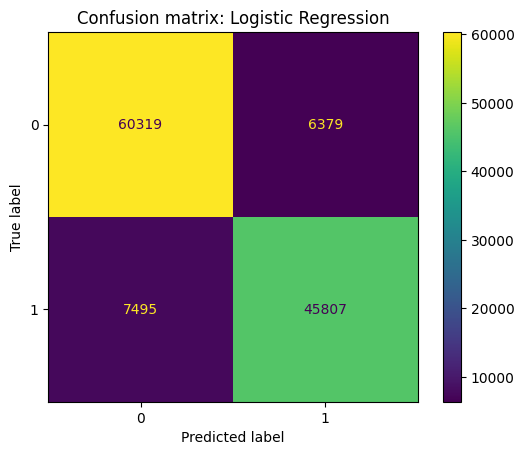

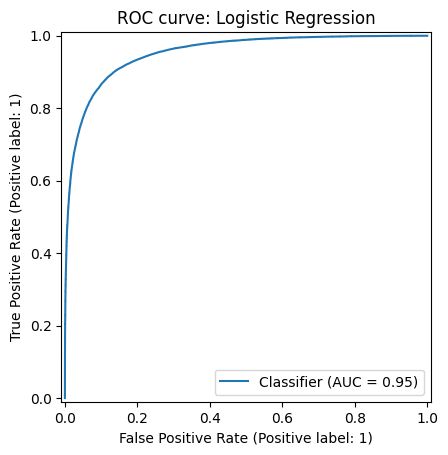

In [16]:
auc_lr = evaluate_sklearn_model(
    pipe_lr,
    X_train,
    y_train,
    X_val,
    y_val,
    title="Logistic Regression",
)


## 5.2 Random Forest

Случайный лес не требует масштабирования, поэтому используем `pipe_rf` (OHE для категориальных + без `StandardScaler`).


Random Forest | ROC-AUC: 0.9599

Classification report:
              precision    recall  f1-score   support

           0     0.9022    0.9132    0.9077     66698
           1     0.8897    0.8762    0.8829     53302

    accuracy                         0.8968    120000
   macro avg     0.8960    0.8947    0.8953    120000
weighted avg     0.8967    0.8968    0.8967    120000



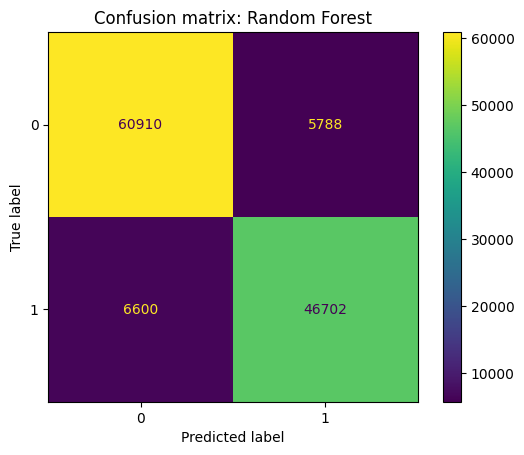

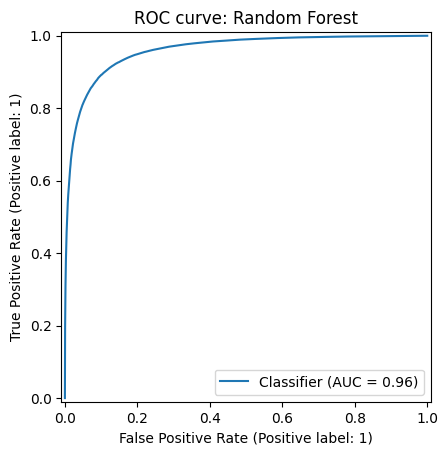

In [17]:
auc_rf = evaluate_sklearn_model(
    pipe_rf,
    X_train,
    y_train,
    X_val,
    y_val,
    title="Random Forest",
)


## 5.3 Neural Network (PyTorch)

Ниже — простая полносвязная сеть (MLP) на PyTorch. Она обучается на подготовленных матрицах `X_train_dense / y_train_dense` и проверяется на `X_val_dense / y_val`.

Если PyTorch не установлен, установи его (CPU-версию) в активном окружении `.venv`.


In [18]:
# Импорт PyTorch
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
except ModuleNotFoundError as e:
    raise ModuleNotFoundError(
        "PyTorch не установлен. Установи его в .venv, затем перезапусти kernel. "
        "Например (CPU): pip install torch"
    ) from e


def set_seed(seed: int = 42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
set_seed(42)


Device: cpu


In [19]:
# Даталоадеры

Xtr = torch.tensor(X_train_dense, dtype=torch.float32)
ytr = torch.tensor(y_train_dense.values, dtype=torch.float32).view(-1, 1)

Xva = torch.tensor(X_val_dense, dtype=torch.float32)
yva = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=1024, shuffle=True)
val_loader = DataLoader(TensorDataset(Xva, yva), batch_size=4096, shuffle=False)

input_dim = Xtr.shape[1]
print("Input dim:", input_dim)


Input dim: 25


In [20]:
# Модель (MLP)

class MLP(nn.Module):
    def __init__(self, in_features: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)


model = MLP(input_dim).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)


MLP(
  (net): Sequential(
    (0): Linear(in_features=25, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)


Epoch 01/10 | train_loss=0.4623 | val_auc=0.9495


Epoch 02/10 | train_loss=0.2842 | val_auc=0.9550


Epoch 03/10 | train_loss=0.2755 | val_auc=0.9566


Epoch 04/10 | train_loss=0.2712 | val_auc=0.9576


Epoch 05/10 | train_loss=0.2671 | val_auc=0.9581


Epoch 06/10 | train_loss=0.2647 | val_auc=0.9585


Epoch 07/10 | train_loss=0.2639 | val_auc=0.9588


Epoch 08/10 | train_loss=0.2619 | val_auc=0.9589


Epoch 09/10 | train_loss=0.2616 | val_auc=0.9590


Epoch 10/10 | train_loss=0.2607 | val_auc=0.9591


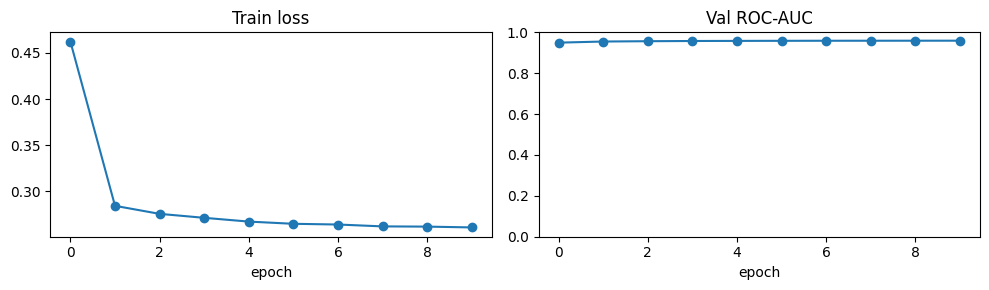


Neural Network (PyTorch) | ROC-AUC: 0.9591152960236189

Classification report:
              precision    recall  f1-score   support

           0     0.8924    0.9202    0.9061     66698
           1     0.8960    0.8611    0.8782     53302

    accuracy                         0.8939    120000
   macro avg     0.8942    0.8906    0.8921    120000
weighted avg     0.8940    0.8939    0.8937    120000



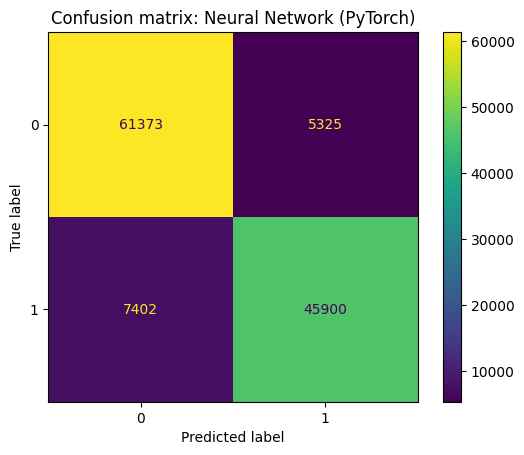

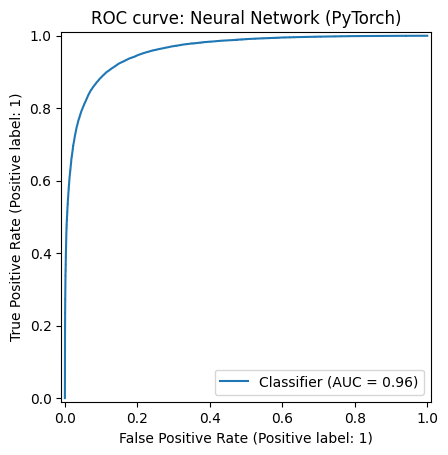

In [21]:
# Обучение + метрики

def predict_proba_torch(model, loader):
    model.eval()
    probs = []
    ys = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            p = torch.sigmoid(logits).cpu().numpy().ravel()
            probs.append(p)
            ys.append(yb.numpy().ravel())
    return np.concatenate(probs), np.concatenate(ys)


epochs = 10
history = {"train_loss": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    model.train()
    running = 0.0
    n = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running += loss.item() * xb.size(0)
        n += xb.size(0)

    train_loss = running / n

    val_proba, val_y = predict_proba_torch(model, val_loader)
    val_auc = roc_auc_score(val_y, val_proba)

    history["train_loss"].append(train_loss)
    history["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d}/{epochs} | train_loss={train_loss:.4f} | val_auc={val_auc:.4f}")

# Графики обучения
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], marker="o")
plt.title("Train loss")
plt.xlabel("epoch")

plt.subplot(1, 2, 2)
plt.plot(history["val_auc"], marker="o")
plt.title("Val ROC-AUC")
plt.xlabel("epoch")
plt.ylim(0.0, 1.0)
plt.tight_layout()
plt.show()

# Итоговая оценка
val_pred = (val_proba >= 0.5).astype(int)
print("\nNeural Network (PyTorch) | ROC-AUC:", roc_auc_score(val_y, val_proba))
print("\nClassification report:")
print(classification_report(val_y.astype(int), val_pred, digits=4))

ConfusionMatrixDisplay.from_predictions(val_y.astype(int), val_pred, values_format="d")
plt.title("Confusion matrix: Neural Network (PyTorch)")
plt.show()

RocCurveDisplay.from_predictions(val_y, val_proba)
plt.title("ROC curve: Neural Network (PyTorch)")
plt.show()
